# NC Parcel Data Sanity Checks

Russell Blessing

## Load libraries

In [ ]:
library(sf)
library(dplyr)
library(ggplot2)
library(DBI)
library(RSQLite)


## Point to directories and data

In [ ]:
# Output directory (external to repo; not tracked by git)
out_dir <- "/proj/mhinolab/users/rbless/data/Obstacles_Output"
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

out_gpkg <- file.path(out_dir, "parcels_study_area.gpkg")
out_csv  <- file.path(out_dir, "parcels_study_area.csv")

study_area_path <- "/proj/mhinolab/projects/obstacles/NC_huc6_data_union_sf/NC_huc6_data_union_sf.shp"
gpkg_path <- "/proj/mhinolab/users/rbless/data/parcels/NC_Parcels_all.gpkg"
parcels_layer <- "nc_parcels_poly" # update if st_layers() indicates otherwise



cols_keep_attr <- c("cntyfips","parno","altparno","nparno","siteadd","sunit","scity","szip",
                    "mailadd","ownname","ownfrst","ownlast","parval","parusedesc")

dup_path <- file.path(out_dir, "dup_counts_studyarea_cntyfips_parno.rds")

out_layer <- "parcels_study_area"


## Study Area

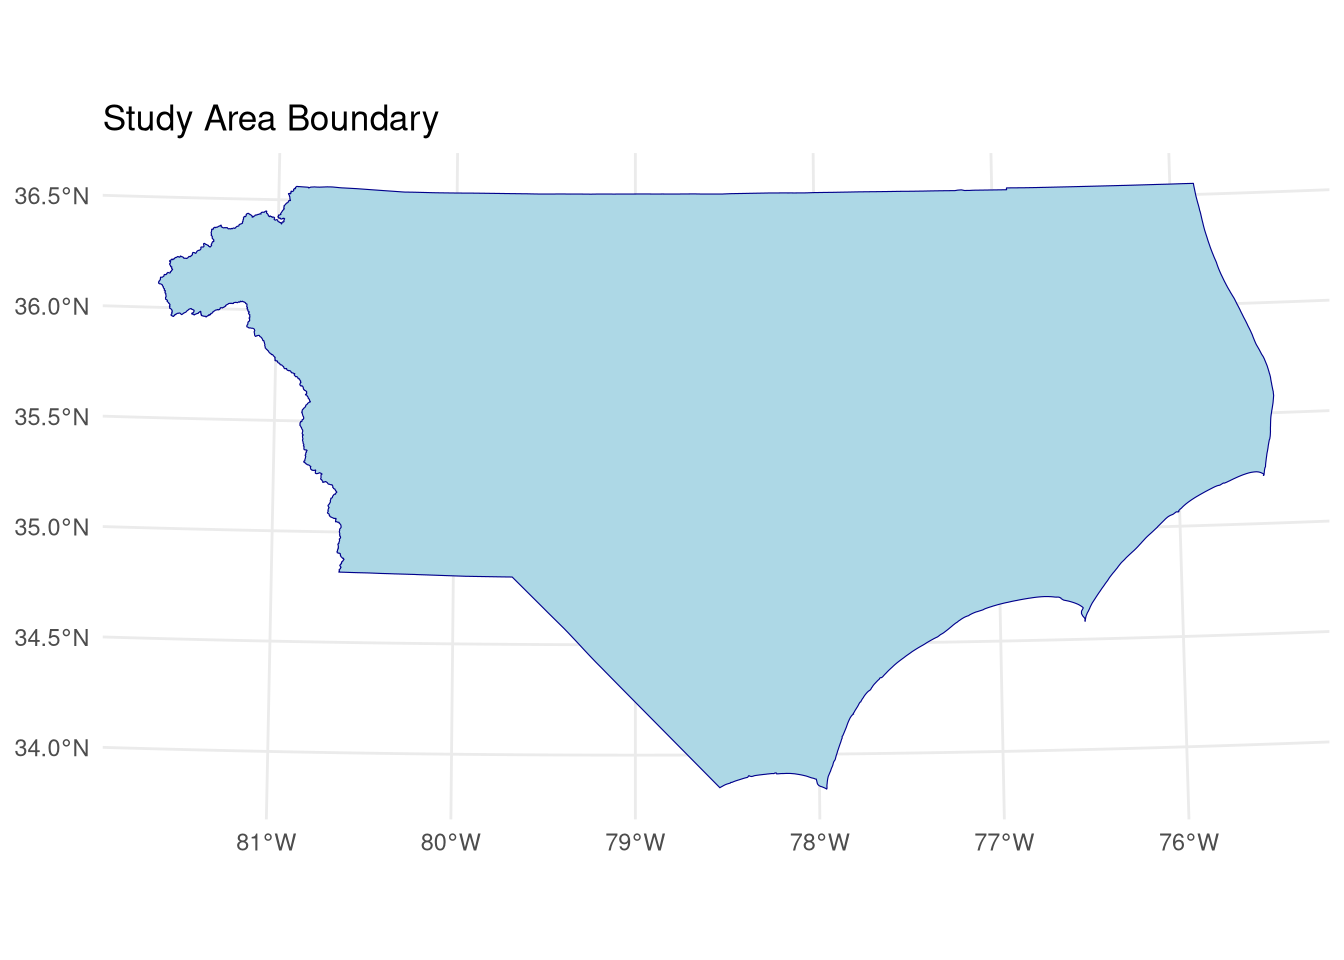

In [ ]:
study_area <- st_read(study_area_path, quiet = TRUE)

study_union <- study_area %>% 
  st_make_valid() %>% 
  st_geometry() %>% 
  st_union() %>% 
  st_sfc(crs = st_crs(study_area)) %>% 
  st_as_sf() %>% 
  st_transform(2264)

study_bbox <- st_bbox(study_union)

ggplot() +
geom_sf(data = study_union, fill = "lightblue", color = "darkblue") +
theme_minimal() +
labs(title = "Study Area Boundary")


## Identify parcel CRS

In [ ]:
# get_layer_crs <- function(gpkg_path, layer) {
#   sql <- sprintf('SELECT * FROM "%s" LIMIT 0', layer)
#   x0 <- sf::st_read(gpkg_path, query = sql, quiet = TRUE)
#   sf::st_crs(x0)
# }
# 
# parcel_crs <- get_layer_crs(gpkg_path, parcels_layer)
# parcel_crs$epsg   # should be 2264


In [ ]:
x0 <- st_read(gpkg_path,
              query = sprintf('SELECT * FROM "%s" LIMIT 0', parcels_layer),
              quiet = TRUE)
geom_col <- attr(x0, "sf_column")

cols_keep <- c(geom_col, cols_keep_attr)


## Parcels Attributes to Keep

-   cntyfips: The county FIPS code 3-digit
-   parno: The local parcel number for the parcel record
-   altparno: Alternative or local parcel number.
-   nparno: the local parcel number with the state and county FIPS added to the beginning of the local parcel number.
-   siteadd: the full site address as a single field
-   sunit:

In [ ]:
# Open connection just for this query
con <- dbConnect(RSQLite::SQLite(), gpkg_path)

sql <- sprintf('
  SELECT DISTINCT CAST(cntyfips AS TEXT) AS cntyfips
  FROM "%s"
  WHERE cntyfips IS NOT NULL
  ORDER BY cntyfips
', parcels_layer)

cntys <- dbGetQuery(con, sql)$cntyfips

dbDisconnect(con)

cntys <- cntys[!is.na(cntys) & nzchar(cntys)]
length(cntys)


[1] 100

[1] "001" "003" "005" "007" "009" "011"

In [ ]:
if (file.exists(out_gpkg) && file.size(out_gpkg) < 10^6) file.remove(out_gpkg)

if (!file.exists(out_gpkg)) {

  con <- DBI::dbConnect(RSQLite::SQLite(), gpkg_path)
  on.exit(DBI::dbDisconnect(con), add = TRUE)


  cols_sql <- paste(sprintf('"%s"', cols_keep), collapse = ", ")
  wrote_any <- FALSE
  t0 <- Sys.time()

  for (i in seq_along(cntys)) {
    c <- cntys[[i]]
    if (i %% 5 == 0) {
      message(sprintf("[%d/%d] county=%s elapsed=%.1f min",
                      i, length(cntys), c,
                      as.numeric(difftime(Sys.time(), t0, units="mins"))))
    }

    c_q <- DBI::dbQuoteString(con, c)

    sql <- sprintf(
      'SELECT %s FROM "%s" WHERE CAST(cntyfips AS TEXT) = %s',
      cols_sql, parcels_layer, c_q
    )

    x <- sf::st_read(gpkg_path, query = sql, quiet = TRUE)
    if (nrow(x) == 0) next

    # cheap spatial restrictions
    x <- sf::st_crop(x, study_bbox)
    if (nrow(x) == 0) next

    x_in <- sf::st_filter(x, study_union, .predicate = sf::st_intersects)
    if (nrow(x_in) == 0) next

    sf::st_write(
      x_in,
      out_gpkg,
      layer = out_layer,
      append = wrote_any,
      quiet = TRUE
    )

    wrote_any <- TRUE
    rm(x, x_in); gc()
  }

  if (!wrote_any) stop("No parcels were written—check CRS/study area.")
  message("Wrote: ", out_gpkg)

} else {
  message("Already exists: ", out_gpkg)
}


Already exists: /proj/mhinolab/users/rbless/data/Obstacles_Output/parcels_study_area.gpkg

Clipped gpkg size: 2841.7 MB

In [ ]:
if (!file.exists(dup_path)) {

  if (!file.exists(out_gpkg)) {
    stop("Clipped parcels gpkg not found yet: ", out_gpkg)
  }

  # Read ONLY the fields needed from the clipped layer
  sql <- sprintf('SELECT cntyfips, parno FROM "%s"', out_layer)

  x <- sf::st_read(out_gpkg, query = sql, quiet = TRUE) |>
    sf::st_drop_geometry()

  dup_counts <- x |>
    dplyr::count(cntyfips, parno, name = "n") |>
    dplyr::filter(n > 1) |>
    dplyr::arrange(dplyr::desc(n), cntyfips, parno)

  saveRDS(dup_counts, dup_path)
  message("Saved: ", dup_path)

} else {
  dup_counts <- readRDS(dup_path)
  message("Loaded existing: ", dup_path)
}


Loaded existing: /proj/mhinolab/users/rbless/data/Obstacles_Output/dup_counts_studyarea_cntyfips_parno.rds

      cntyfips               parno     n
1          001          8746943210     2
2          001          8747263688     2
3          001          8777902988     2
4          001          8799043845     2
5          001          8841314261     2
6          001          8842404846     2
7          001          8843177020     2
8          001          8843178173     2
9          001          8843191320     2
10         001          8844705965     2
11         001          8846304714     2
12         001          8846710980     2
13         001          8847156450     2
14         001          8849901634     2
15         001          8854315732     4
16         001          8854374400     2
17         001          8856652922     2
18         001          8857055824     2
19         001          8862258992     2
20         001          8864763338     2
21         001          8865881156     2
22         001          8870497013     2
23         001          8870960470     2
24         001  